In [1]:
# !pip install -q sentence-transformers scikit-learn umap-learn matplotlib seaborn pandas
import os, re, gc, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

from sentence_transformers import SentenceTransformer, losses, InputExample
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader

RNG = 42
np.random.seed(RNG)

# ------- knobs you may want to tweak -------
ENCODER_NAME = "sentence-transformers/all-mpnet-base-v2"   # swap with e5/bge/nomic as desired
BATCH_SIZE   = 128
POOL_METHOD  = "topk"    # "max" | "mean" | "topk"
TOPK         = 3
SAVE_DIR     = "./ckpts_ucf"
os.makedirs(SAVE_DIR, exist_ok=True)


/users/eleves-a/2024/elio.samaha/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("UCFCrime_Train.json", "r", encoding="utf-8") as f:
    raw = json.load(f)

rows = []
for video, info in raw.items():
    # label = prefix before digits; also normalize the two normals ("Normal_Videos", "Normal_Videos_")
    lab_raw = re.sub(r"\d+.*", "", video)        # e.g., "Abuse001_x264" -> "Abuse"
    lab_norm = "Normal_Videos" if lab_raw.startswith("Normal_Videos") else lab_raw
    rows.append({
        "video": video,
        "label": lab_norm,
        "text": " ".join(info["sentences"]),
        "n_sentences": len(info["sentences"]),
        "duration": info.get("duration", np.nan)
    })

df_vid = pd.DataFrame(rows).sort_values("video").reset_index(drop=True)
print(df_vid.shape, df_vid["label"].value_counts())


(1165, 5) label
Normal_Videos    589
RoadAccidents    106
Robbery           84
Stealing          66
Burglary          64
Arrest            42
Fighting          37
Abuse             36
Shooting          31
Shoplifting       30
Vandalism         30
Assault           25
Arson             18
Explosion          7
Name: count, dtype: int64


In [3]:
violent_set = {"Abuse","Fighting","Burglary","Robbery","Assault","Shooting","Arrest","Explosion","Arson","Vandalism","Stealing","Shoplifting","RoadAccidents"}
df_vid["binary_label"] = np.where(df_vid["label"].isin(violent_set), "Violent", "Non-Violent")
df_vid.head()


,video,label,text,n_sentences,duration,binary_label
0,Abuse001_x264,Abuse,"A woman with short hair, slightly fat, wearing...",9,91.00,Violent
1,Abuse002_x264,Abuse,"At an intersection with smooth traffic, the gr...",22,28.83,Violent
2,Abuse003_x264,Abuse,A woman in black short-sleeves pushed an old m...,28,123.32,Violent
3,Abuse004_x264,Abuse,Two bald policemen in black uniforms held the ...,64,559.82,Violent
4,Abuse005_x264,Abuse,The prison guard wearing black trousers and gr...,12,31.65,Violent


In [4]:
def encode_texts(texts, encoder_name=ENCODER_NAME, batch=BATCH_SIZE, save_path=None):
    enc = SentenceTransformer(encoder_name)
    embs = enc.encode(
        texts, batch_size=batch, convert_to_numpy=True,
        normalize_embeddings=True, show_progress_bar=True
    )
    if save_path:
        np.save(save_path, embs)
    return enc, embs

encoder, X0 = encode_texts(df_vid["text"].tolist(),
                           encoder_name=ENCODER_NAME,
                           batch=BATCH_SIZE,
                           save_path=f"{SAVE_DIR}/embeddings_base.npy")

# Keep a copy of the *base* embeddings for comparison
X_base = X0.copy()


Batches: 100%|██████████| 10/10 [00:04<00:00,  2.21it/s]


In [5]:
# Build pair examples
examples = []
for t, b in zip(df_vid["text"], df_vid["binary_label"]):
    examples.append(InputExample(texts=[t, t], label=1.0))  # positive

viol = df_vid[df_vid["binary_label"]=="Violent"]["text"].tolist()
nonv = df_vid[df_vid["binary_label"]=="Non-Violent"]["text"].tolist()
for i, vt in enumerate(viol):
    nv = nonv[i % len(nonv)]
    examples.append(InputExample(texts=[vt, nv], label=0.0))  # negative

train_loader = DataLoader(examples, shuffle=True, batch_size=8)
train_loss   = losses.CosineSimilarityLoss(model=encoder)

encoder.fit([(train_loader, train_loss)], epochs=1, warmup_steps=10, show_progress_bar=True)

# --- persist tuned model and re-encode ---
tuned_dir = f"{SAVE_DIR}/contrastive_binary_mpnet"
encoder.save(tuned_dir)

encoder_tuned = SentenceTransformer(tuned_dir)         # <- reload to *use* the tuned weights
X_tuned = encoder_tuned.encode(
    df_vid["text"].tolist(), batch_size=BATCH_SIZE, convert_to_numpy=True, normalize_embeddings=True,
    show_progress_bar=True
)
np.save(f"{SAVE_DIR}/embeddings_tuned.npy", X_tuned)


Step,Training Loss


Batches: 100%|██████████| 10/10 [00:04<00:00,  2.20it/s]


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

[VAL] best threshold = 0.35 (macro-F1 = 0.936)

[TEST] Classification report:
              precision    recall  f1-score   support

 Non-Violent      0.958     0.958     0.958       118
     Violent      0.957     0.957     0.957       115

    accuracy                          0.957       233
   macro avg      0.957     0.957     0.957       233
weighted avg      0.957     0.957     0.957       233



<Figure size 700x600 with 0 Axes>

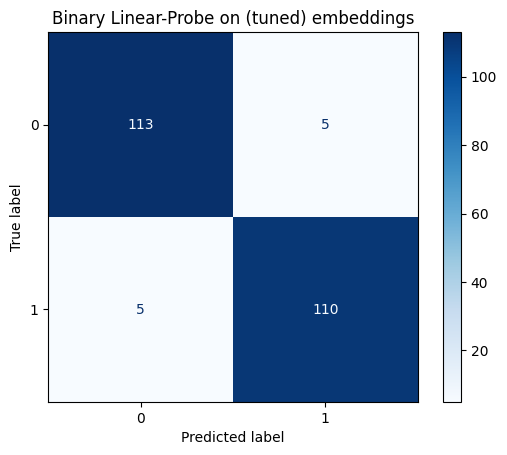

In [6]:
# Choose embeddings to probe:
EMBS = X_tuned  # or X_base if you want “pre-tuning” baseline

y_bin = (df_vid["binary_label"]=="Violent").astype(int).values

X_tr, X_temp, y_tr, y_temp = train_test_split(EMBS, y_bin, test_size=0.4, stratify=y_bin, random_state=RNG)
X_val, X_te,  y_val, y_te  = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RNG)

clf = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=4)
clf.fit(X_tr, y_tr)

# threshold sweep on validation
val_p = clf.predict_proba(X_val)[:,1]
ths = np.linspace(0.1,0.9,17)
best_t, best_f1 = 0.5, -1
for t in ths:
    f1 = f1_score(y_val, (val_p >= t).astype(int), average="macro")
    if f1 > best_f1:
        best_t, best_f1 = t, f1

print(f"[VAL] best threshold = {best_t:.2f} (macro-F1 = {best_f1:.3f})")

# evaluate on test
te_p = clf.predict_proba(X_te)[:,1]
te_y = (te_p >= best_t).astype(int)
print("\n[TEST] Classification report:")
print(classification_report(y_te, te_y, target_names=["Non-Violent","Violent"], digits=3))

plt.figure(figsize=(7,6))
ConfusionMatrixDisplay(confusion_matrix(y_te, te_y)).plot(cmap="Blues", values_format="d")
plt.title("Binary Linear-Probe on (tuned) embeddings")
plt.show()

# persist the probe for reuse
import joblib, json
joblib.dump(clf, f"{SAVE_DIR}/logreg_probe.joblib")
json.dump({"threshold": float(best_t)}, open(f"{SAVE_DIR}/decision_threshold.json","w"))


In [7]:
print("Using encoder from:", encoder_tuned._first_module().auto_model.name_or_path)

# quick geometry check
def avg_crossclass_cosine(X, y):
    a = X[y==0]; b = X[y==1]
    S = cosine_similarity(a, b)
    return S.mean()

print("Avg cross-class cosine (BASE):", avg_crossclass_cosine(X_base, y_bin))
print("Avg cross-class cosine (TUNED):", avg_crossclass_cosine(X_tuned, y_bin))


Using encoder from: ./ckpts_ucf/contrastive_binary_mpnet
Avg cross-class cosine (BASE): 0.34531856
Avg cross-class cosine (TUNED): 0.009052809


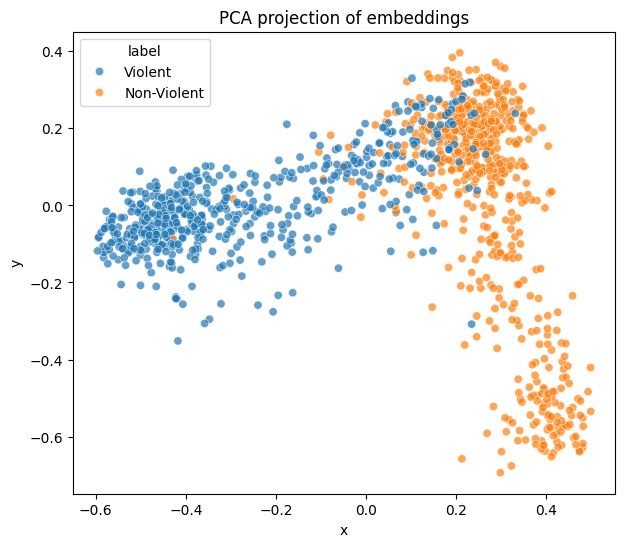

In [8]:
coords = PCA(n_components=2).fit_transform(EMBS)
tmp = pd.DataFrame({"x":coords[:,0],"y":coords[:,1],"label":np.where(y_bin==1,"Violent","Non-Violent")})

plt.figure(figsize=(7,6))
sns.scatterplot(data=tmp, x="x", y="y", hue="label", alpha=0.7)
plt.title("PCA projection of embeddings")
plt.show()


In [9]:
probs = te_p
preds = te_y
test_idx = X_te.shape[0]
# mask_te = np.isin(EMBS, X_te).all(axis=1)  # safe alternative (not used)

# Map back to the original indices using the same two-step splits used when creating X_tr/X_val/X_te
indices = np.arange(len(EMBS))
# first split that produced the "temp" set (test_size=0.4)
_, temp_indices = train_test_split(indices, test_size=0.4, stratify=y_bin, random_state=RNG)
# second split on that temp to produce the final test set (test_size=0.5 on temp -> overall 0.2)
_, te_indices = train_test_split(temp_indices, test_size=0.5, stratify=y_bin[temp_indices], random_state=RNG)

# Sanity check that lengths match
assert len(probs) == len(preds) == len(te_indices) == test_idx, (
	f"Lengths mismatch: probs={len(probs)} preds={len(preds)} te_indices={len(te_indices)} X_te={test_idx}"
)

df_te = df_vid.iloc[te_indices].copy()
df_te["prob_violent"] = probs
df_te["pred"] = preds
df_te["true"] = y_bin[te_indices]

FP = df_te[(df_te["pred"]==1) & (df_te["true"]==0)].sort_values("prob_violent", ascending=False).head(10)
FN = df_te[(df_te["pred"]==0) & (df_te["true"]==1)].sort_values("prob_violent", ascending=True).head(10)

print("\nTop False Positives (pred Violent, actually Non-Violent):")
display(FP[["video","label","prob_violent","text"]].head(5))

print("\nTop False Negatives (pred Non-Violent, actually Violent):")
display(FN[["video","label","prob_violent","text"]].head(5))



Top False Positives (pred Violent, actually Non-Violent):


,video,label,prob_violent,text
393,Normal_Videos202_x264,Normal_Videos,0.816625,The white car drives past from right to left S...
785,Normal_Videos_884_x264,Normal_Videos,0.728234,There are many vehicles running outside the wi...
514,Normal_Videos339_x264,Normal_Videos,0.609684,"On a road, there are several cars parked, sev..."
512,Normal_Videos337_x264,Normal_Videos,0.433414,A blond woman in black walked to the door and ...
794,Normal_Videos_893_x264,Normal_Videos,0.371888,A man comes to get something from the shelf A ...



Top False Negatives (pred Non-Violent, actually Violent):


,video,label,prob_violent,text
1038,Shooting032_x264,Shooting,0.059422,The end of the street is a T-intersection with...
953,Robbery030_x264,Robbery,0.124600,The screen lights up with three men entering t...
1048,Shoplifting012_x264,Shoplifting,0.130918,A woman wearing gorgeous traditional Indian cl...
1128,Stealing070_x264,Stealing,0.175327,Two people on the sidewalk near a parked car o...
1034,Shooting028_x264,Shooting,0.301913,There is an old man holding something in front...


In [10]:
# ==============================================
# BINARY ERROR ANALYSIS: Why is the model wrong?
# ==============================================

df_test = df_vid.iloc[te_indices].copy()
df_test["prob"] = te_p
df_test["pred"] = te_y
df_test["true"] = y_bin[te_indices]

# classify errors
FP = df_test[(df_test["pred"] == 1) & (df_test["true"] == 0)].copy()
FN = df_test[(df_test["pred"] == 0) & (df_test["true"] == 1)].copy()

print(f"False Positives: {len(FP)}")
print(f"False Negatives: {len(FN)}")

# --- add useful diagnostics ---
FP["text_len"] = FP["text"].str.split().str.len()
FN["text_len"] = FN["text"].str.split().str.len()

violence_keywords = [
    "hit", "attack", "fight", "gun", "shot", "police",
    "explosion", "fire", "burn", "injured", "weapon", "punch"
]

FP["keyword_count"] = FP["text"].apply(lambda t: sum(k in t.lower() for k in violence_keywords))
FN["keyword_count"] = FN["text"].apply(lambda t: sum(k in t.lower() for k in violence_keywords))

# compute semantic similarity to nearest opposite class in embedding space
def nearest_opposite_similarity(idx):
    v = EMBS[idx].reshape(1, -1)
    if df_vid.iloc[idx]["binary_label"] == "Violent":
        pool = EMBS[df_vid["binary_label"] == "Non-Violent"]
    else:
        pool = EMBS[df_vid["binary_label"] == "Violent"]
    return cosine_similarity(v, pool).max()

FP["nearest_sim"] = [
    nearest_opposite_similarity(i)
    for i in te_indices[(te_y == 1) & (y_bin[te_indices] == 0)]
]
FN["nearest_sim"] = [
    nearest_opposite_similarity(i)
    for i in te_indices[(te_y == 0) & (y_bin[te_indices] == 1)]
]

print("\n=== TOP FALSE POSITIVES (model thinks violent) ===")
display(
    FP.sort_values("prob", ascending=False)[
        ["video", "label", "prob", "keyword_count", "nearest_sim", "text"]
    ].head(5)
)

print("\n=== TOP FALSE NEGATIVES (model misses violence) ===")
display(
    FN.sort_values("prob", ascending=True)[
        ["video", "label", "prob", "keyword_count", "nearest_sim", "text"]
    ].head(5)
)

print("\n=== PATTERNS IN ERRORS ===")
print("\nFP: keyword freq mean =", FP["keyword_count"].mean())
print("FN: keyword freq mean =", FN["keyword_count"].mean())
print("\nFP: nearest similarity mean =", FP["nearest_sim"].mean())
print("FN: nearest similarity mean =", FN["nearest_sim"].mean())
print("\nFP: text length mean =", FP["text_len"].mean())
print("FN: text length mean =", FN["text_len"].mean())


False Positives: 5
False Negatives: 5

=== TOP FALSE POSITIVES (model thinks violent) ===


,video,label,prob,keyword_count,nearest_sim,text
393,Normal_Videos202_x264,Normal_Videos,0.816625,1,0.503211,The white car drives past from right to left S...
785,Normal_Videos_884_x264,Normal_Videos,0.728234,0,0.466210,There are many vehicles running outside the wi...
514,Normal_Videos339_x264,Normal_Videos,0.609684,1,0.333343,"On a road, there are several cars parked, sev..."
512,Normal_Videos337_x264,Normal_Videos,0.433414,0,0.338274,A blond woman in black walked to the door and ...
794,Normal_Videos_893_x264,Normal_Videos,0.371888,1,0.335307,A man comes to get something from the shelf A ...



=== TOP FALSE NEGATIVES (model misses violence) ===


,video,label,prob,keyword_count,nearest_sim,text
1038,Shooting032_x264,Shooting,0.059422,3,0.417051,The end of the street is a T-intersection with...
953,Robbery030_x264,Robbery,0.124600,0,0.450068,The screen lights up with three men entering t...
1048,Shoplifting012_x264,Shoplifting,0.130918,0,0.371245,A woman wearing gorgeous traditional Indian cl...
1128,Stealing070_x264,Stealing,0.175327,0,0.422560,Two people on the sidewalk near a parked car o...
1034,Shooting028_x264,Shooting,0.301913,0,0.470358,There is an old man holding something in front...



=== PATTERNS IN ERRORS ===

FP: keyword freq mean = 0.6
FN: keyword freq mean = 0.6

FP: nearest similarity mean = 0.39526898
FN: nearest similarity mean = 0.42625627

FP: text length mean = 114.6
FN: text length mean = 568.2


/users/eleves-a/2024/elio.samaha/.conda/envs/env-lab6/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[TEST] Classification report (multi-class):
               precision    recall  f1-score   support

        Abuse      0.750     0.429     0.545         7
       Arrest      0.800     1.000     0.889         8
        Arson      0.750     0.750     0.750         4
      Assault      0.500     0.400     0.444         5
     Burglary      0.846     0.846     0.846        13
    Explosion      1.000     0.500     0.667         2
     Fighting      0.556     0.714     0.625         7
Normal_Videos      0.955     0.898     0.926       118
RoadAccidents      0.955     1.000     0.977        21
      Robbery      0.765     0.765     0.765        17
     Shooting      0.500     0.500     0.500         6
  Shoplifting      0.333     0.667     0.444         6
     Stealing      0.600     0.692     0.643        13
    Vandalism      0.400     0.333     0.364         6

     accuracy                          0.820       233
    macro avg      0.694     0.678     0.670       233
 weighted avg     

<Figure size 1000x800 with 0 Axes>

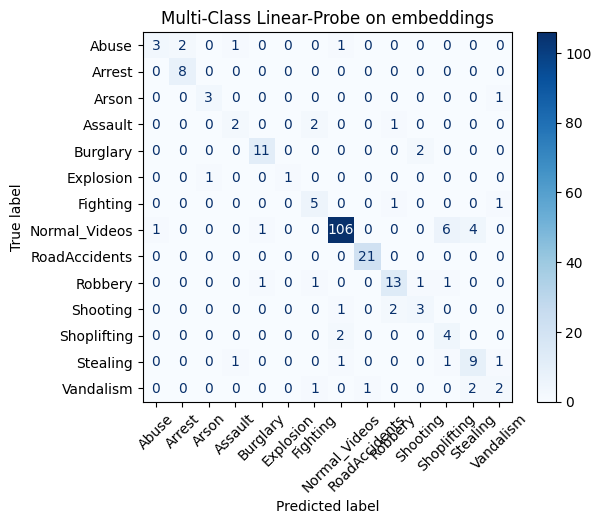

In [11]:
# ==============================================
# MULTI-CLASS LINEAR PROBE
# ==============================================

labels_mc = df_vid["label"].values
le = LabelEncoder().fit(labels_mc)
y_mc = le.transform(labels_mc)

# We split EMBS and also carry along the df indices to reconstruct df rows
indices_all = df_vid.index.values

X_train_mc, X_test_mc, y_train_mc, y_test_mc, idx_train_mc, idx_test_mc = train_test_split(
    EMBS,
    y_mc,
    indices_all,
    test_size=0.2,
    stratify=y_mc,
    random_state=RNG
)

clf_mc = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=4,
    multi_class="multinomial"
)
clf_mc.fit(X_train_mc, y_train_mc)

y_pred_mc = clf_mc.predict(X_test_mc)

print("\n[TEST] Classification report (multi-class):")
print(classification_report(y_test_mc, y_pred_mc, target_names=le.classes_, digits=3))

plt.figure(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix(y_test_mc, y_pred_mc),
    display_labels=le.classes_
).plot(cmap="Blues", xticks_rotation=45)
plt.title("Multi-Class Linear-Probe on embeddings")
plt.show()


In [12]:
# ==============================================
# MULTI-CLASS ERROR ANALYSIS
# ==============================================

df_test_mc = df_vid.iloc[idx_test_mc].copy()
df_test_mc["pred"] = y_pred_mc
df_test_mc["true"] = y_test_mc

probs_mc = clf_mc.predict_proba(X_test_mc)
df_test_mc["prob_max"] = probs_mc.max(axis=1)

# Identify errors / corrects
errors = df_test_mc[df_test_mc["pred"] != df_test_mc["true"]].copy()
correct = df_test_mc[df_test_mc["pred"] == df_test_mc["true"]].copy()

print(f"Total test samples (multi-class): {len(df_test_mc)}")
print(f"✅ Correct: {len(correct)}")
print(f"❌ Errors: {len(errors)}")

# Add diagnostics
errors["text_len"] = errors["text"].str.split().str.len()

violence_keywords_mc = [
    "hit","attack","fight","gun","shot","shoot","police","arrest",
    "explosion","fire","burn","injured","weapon","punch","steal","rob"
]

errors["keyword_count"] = errors["text"].apply(
    lambda t: sum(k in t.lower() for k in violence_keywords_mc)
)

# Build centroids per multi-class label in embedding space
centroids_mc = {}
for lbl in le.classes_:
    mask = df_vid["label"] == lbl
    centroids_mc[lbl] = EMBS[mask].mean(axis=0)

# attach embeddings for test set rows (aligned with X_test_mc)
errors = errors.reset_index(drop=True)
errors["embedding"] = list(X_test_mc[errors.index])

def centroid_sim(row):
    pred_label = le.classes_[row["pred"]]  # map back to label string
    return cosine_similarity(
        row["embedding"].reshape(1, -1),
        centroids_mc[pred_label].reshape(1, -1)
    )[0][0]

errors["centroid_sim"] = errors.apply(centroid_sim, axis=1)

print("\n=== HIGH-CONFIDENCE WRONG PREDICTIONS (multi-class) ===")
display(
    errors.sort_values("prob_max", ascending=False)[
        ["video", "label", "true", "pred", "prob_max", "keyword_count", "text_len", "text"]
    ].head(5)
)

print("\n=== TOP CONFUSION PAIRS (true → predicted) ===")
# convert numeric true/pred back to label names for readability
errors_named = errors.copy()
errors_named["true_lbl"] = errors_named["true"].apply(lambda i: le.classes_[i])
errors_named["pred_lbl"] = errors_named["pred"].apply(lambda i: le.classes_[i])

conf_pairs = errors_named.groupby(["true_lbl", "pred_lbl"]).size().sort_values(ascending=False)
display(conf_pairs.head(10))

print("\n=== ERROR PATTERNS (multi-class) ===")
print("Mean text length (errors):", errors["text_len"].mean())
print("Mean keyword count (errors):", errors["keyword_count"].mean())
print("Mean centroid similarity (errors):", errors["centroid_sim"].mean())


Total test samples (multi-class): 233
✅ Correct: 191
❌ Errors: 42

=== HIGH-CONFIDENCE WRONG PREDICTIONS (multi-class) ===


,video,label,true,pred,prob_max,keyword_count,text_len,text
6,Shooting012_x264,Shooting,10,9,0.701770,3,100,Someone in the distance opened the trunk of t...
13,Normal_Videos073_x264,Normal_Videos,7,11,0.622196,1,228,"In a room, a man wearing a white shirt, black ..."
10,Explosion002_x264,Explosion,5,2,0.600804,3,123,A man in blue is walking with something in his...
21,Robbery064_x264,Robbery,9,10,0.584565,2,62,A woman is standing and playing in the corner....
7,Normal_Videos197_x264,Normal_Videos,7,11,0.529038,1,162,The woman in the gray top went out while turni...



=== TOP CONFUSION PAIRS (true → predicted) ===


true_lbl       pred_lbl     
Normal_Videos  Shoplifting      6
               Stealing         4
Abuse          Arrest           2
Assault        Fighting         2
Shoplifting    Normal_Videos    2
Shooting       Robbery          2
Burglary       Shooting         2
Vandalism      Stealing         2
Arson          Vandalism        1
Abuse          Normal_Videos    1
dtype: int64


=== ERROR PATTERNS (multi-class) ===
Mean text length (errors): 192.02380952380952
Mean keyword count (errors): 1.2380952380952381
Mean centroid similarity (errors): 0.22920781
